In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn nltk joblib -q
print("✅ Libraries ready")

✅ Libraries ready


In [2]:
# CELL 2 — Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import io, re, string, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk, joblib

from google.colab        import files
from nltk.corpus         import stopwords
from nltk.stem           import PorterStemmer

from sklearn.model_selection         import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm                     import LinearSVC
from sklearn.pipeline                import Pipeline
from sklearn.metrics                 import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

nltk.download('stopwords', quiet=True)
warnings.filterwarnings("ignore")
print("✅ All imports done")


✅ All imports done


In [3]:
# CELL 3 — Upload CSV  (click the button that appears)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📂 Click 'Choose Files' and upload your CSV:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# ── keep only the 3 columns we need ──
df = df[['title', 'text', 'label']].copy()

print(f"\n✅ Loaded '{filename}'  →  {df.shape[0]} rows")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()



📂 Click 'Choose Files' and upload your CSV:


Saving improved_fake_news_dataset2.csv to improved_fake_news_dataset2.csv

✅ Loaded 'improved_fake_news_dataset2.csv'  →  123954 rows

Label distribution:
label
1    61977
0    61977
Name: count, dtype: int64

Missing values:
title    33452
text         0
label        0
dtype: int64


,title,text,label
0,NaN,Embargo on Phillipines - withdraw our military...,1
1,Especially sea lay son hear.,too win central main bag save common she famil...,1
2,Russian oil giant Rosneft to restore Romanov p...,Russian oil giant Rosneft to restore Romanov p...,1
3,NaN,the club world cup is here our representative ...,0
4,NaN,"the ismaili club s board of directors, headed ...",1


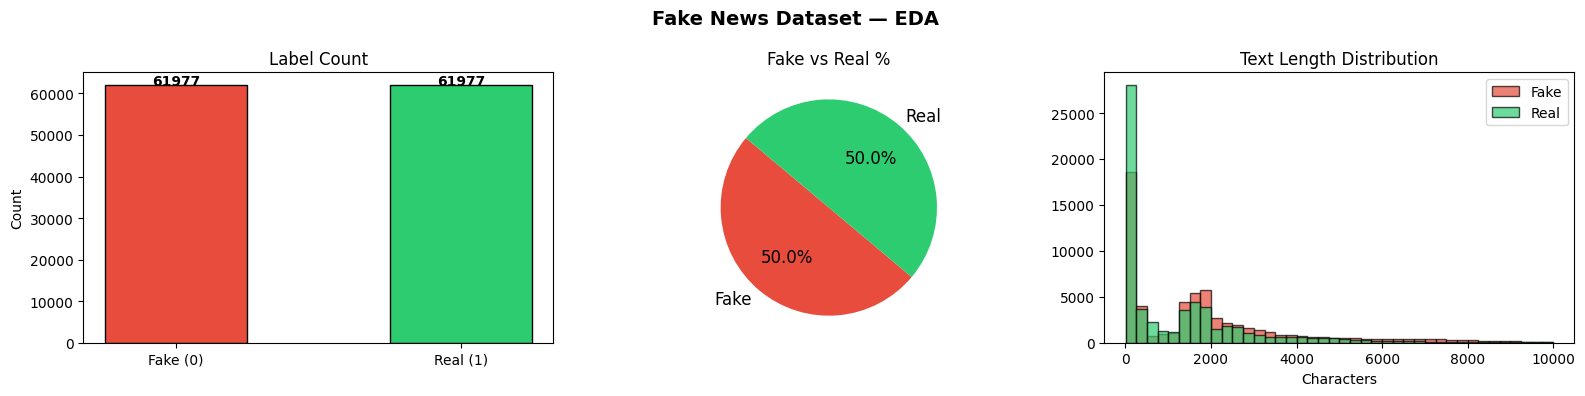

✅ EDA done


In [4]:
# CELL 4 — EDA Plots
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
counts = df['label'].value_counts()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Fake News Dataset — EDA", fontsize=14, fontweight='bold')

# bar
axes[0].bar(['Fake (0)', 'Real (1)'],
            [counts.get(0,0), counts.get(1,0)],
            color=['#e74c3c','#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Label Count')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')

# pie
axes[1].pie([counts.get(0,0), counts.get(1,0)],
            labels=['Fake','Real'], colors=['#e74c3c','#2ecc71'],
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize':12})
axes[1].set_title('Fake vs Real %')

# text length
df['text_len'] = df['text'].astype(str).apply(len)
axes[2].hist(df[df['label']==0]['text_len'], bins=40, alpha=0.7,
             color='#e74c3c', label='Fake', edgecolor='black')
axes[2].hist(df[df['label']==1]['text_len'], bins=40, alpha=0.7,
             color='#2ecc71', label='Real', edgecolor='black')
axes[2].set_title('Text Length Distribution')
axes[2].set_xlabel('Characters')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA done")


In [8]:
# CELL 5 — Preprocessing  (title + text  →  cleaned)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STOPWORDS = set(stopwords.words('english'))
stemmer   = PorterStemmer()

def clean_text(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)        # URLs
    text = re.sub(r'<[^>]+>', '', text)                 # HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\d+', '', text)                     # digits
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [stemmer.stem(w)
              for w in text.split()
              if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

print("⏳ Cleaning title + text ...")

# Combine title and text — both carry useful signal
df['cleaned'] = (df['title'].astype(str) + ' ' + df['text'].astype(str)).apply(clean_text)

# Drop rows with empty cleaned text or missing label
df.dropna(subset=['label'], inplace=True)
df = df[df['cleaned'].str.strip() != ''].reset_index(drop=True)

print(f"✅ Done — {len(df)} clean rows remain")
print("\nSample cleaned row:")
print(df['cleaned'].iloc[0][:250])



⏳ Cleaning title + text ...
✅ Done — 123954 clean rows remain

Sample cleaned row:
nan embargo phillipin withdraw militari watch beg crumb


In [9]:
# CELL 6 — Train / Test Split  (80 / 20)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
X = df['cleaned']
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train : {len(X_train)} samples")
print(f"Test  : {len(X_test)}  samples")



Train : 99163 samples
Test  : 24791  samples


In [10]:
# CELL 7 — Build & Train SVM Pipeline
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = 50000,
        ngram_range  = (1, 2),   # unigrams + bigrams
        sublinear_tf = True,     # log-scale TF
        min_df = 2,
        max_df = 0.95
    )),
    ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=42))
])

print("⏳ Training SVM ...")
pipeline.fit(X_train, y_train)
print("✅ Training complete!")


⏳ Training SVM ...
✅ Training complete!


In [11]:
# CELL 8 — All Evaluation Scores
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
y_pred   = pipeline.predict(X_test)
y_scores = pipeline.decision_function(X_test)

acc   = accuracy_score (y_test, y_pred)
pre_w = precision_score(y_test, y_pred, average='weighted')
rec_w = recall_score   (y_test, y_pred, average='weighted')
f1_w  = f1_score       (y_test, y_pred, average='weighted')
pre_m = precision_score(y_test, y_pred, average='macro')
rec_m = recall_score   (y_test, y_pred, average='macro')
f1_m  = f1_score       (y_test, y_pred, average='macro')
f1_0  = f1_score       (y_test, y_pred, pos_label=0)   # Fake class
f1_1  = f1_score       (y_test, y_pred, pos_label=1)   # Real class
auc   = roc_auc_score  (y_test, y_scores)

print("\n╔══════════════════════════════════════════════════════╗")
print("║         📊  ALL EVALUATION SCORES — SVM             ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Accuracy                      : {acc:.4f}  ({acc*100:.2f}%)  ║")
print(f"║  Precision   (weighted)        : {pre_w:.4f}               ║")
print(f"║  Recall      (weighted)        : {rec_w:.4f}               ║")
print(f"║  F1 Score    (weighted)        : {f1_w:.4f}               ║")
print(f"║  Precision   (macro)           : {pre_m:.4f}               ║")
print(f"║  Recall      (macro)           : {rec_m:.4f}               ║")
print(f"║  F1 Score    (macro)           : {f1_m:.4f}               ║")
print(f"║  F1 — Fake class  (label=0)    : {f1_0:.4f}               ║")
print(f"║  F1 — Real class  (label=1)    : {f1_1:.4f}               ║")
print(f"║  ROC-AUC                       : {auc:.4f}               ║")
print("╚══════════════════════════════════════════════════════╝")

print("\n📋 Per-class Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Fake (0)', 'Real (1)'], digits=4))




╔══════════════════════════════════════════════════════╗
║         📊  ALL EVALUATION SCORES — SVM             ║
╠══════════════════════════════════════════════════════╣
║  Accuracy                      : 0.8550  (85.50%)  ║
║  Precision   (weighted)        : 0.8550               ║
║  Recall      (weighted)        : 0.8550               ║
║  F1 Score    (weighted)        : 0.8550               ║
║  Precision   (macro)           : 0.8550               ║
║  Recall      (macro)           : 0.8550               ║
║  F1 Score    (macro)           : 0.8550               ║
║  F1 — Fake class  (label=0)    : 0.8559               ║
║  F1 — Real class  (label=1)    : 0.8540               ║
║  ROC-AUC                       : 0.9459               ║
╚══════════════════════════════════════════════════════╝

📋 Per-class Classification Report:
              precision    recall  f1-score   support

    Fake (0)     0.8504    0.8616    0.8559     12396
    Real (1)     0.8597    0.8484    0.8540     123

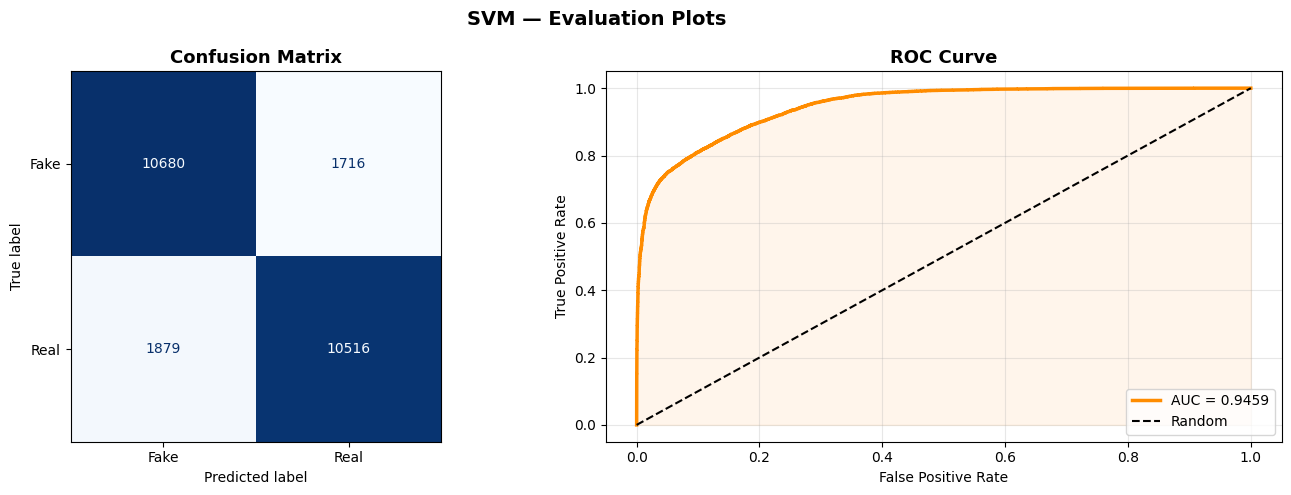

In [12]:
# CELL 9 — Confusion Matrix + ROC Curve
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SVM — Evaluation Plots", fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fake','Real']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='darkorange')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()



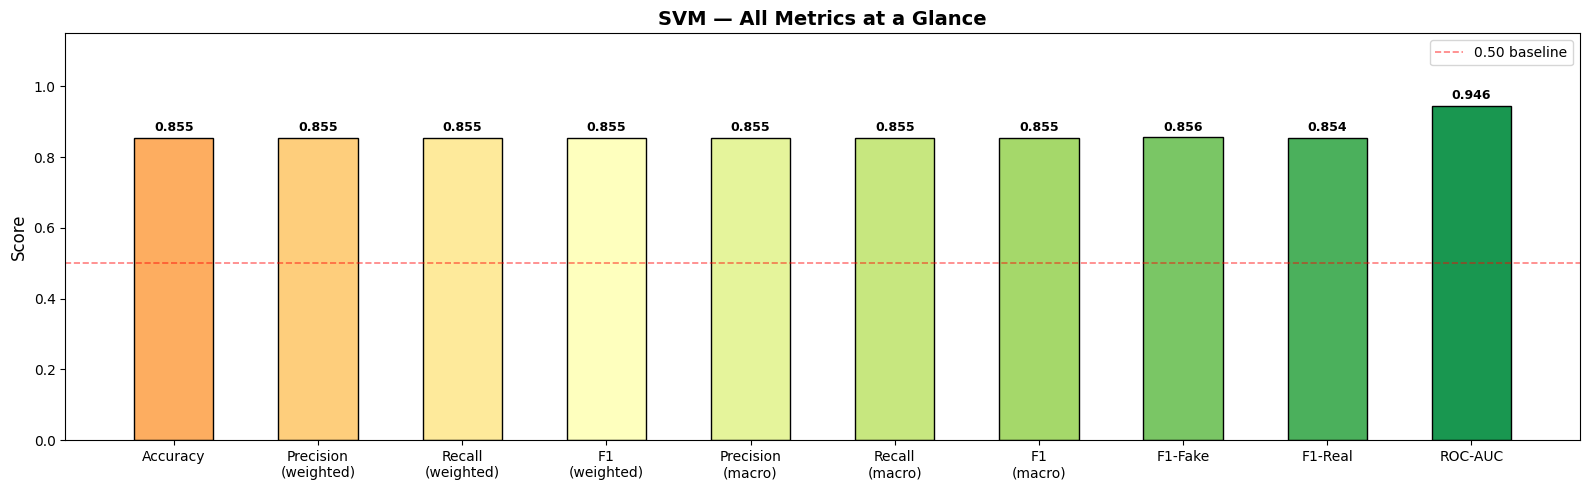

In [13]:
# CELL 10 — Scores Bar Chart
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
metric_names = ['Accuracy','Precision\n(weighted)','Recall\n(weighted)',
                'F1\n(weighted)','Precision\n(macro)','Recall\n(macro)',
                'F1\n(macro)','F1-Fake','F1-Real','ROC-AUC']
metric_vals  = [acc, pre_w, rec_w, f1_w, pre_m, rec_m, f1_m, f1_0, f1_1, auc]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(metric_names, metric_vals,
              color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(metric_vals))),
              edgecolor='black', width=0.55)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('SVM — All Metrics at a Glance', fontsize=14, fontweight='bold')
ax.axhline(0.5, color='red', linestyle='--', lw=1.2, alpha=0.5, label='0.50 baseline')
ax.legend()
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h+0.01,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('scores.png', dpi=150, bbox_inches='tight')
plt.show()



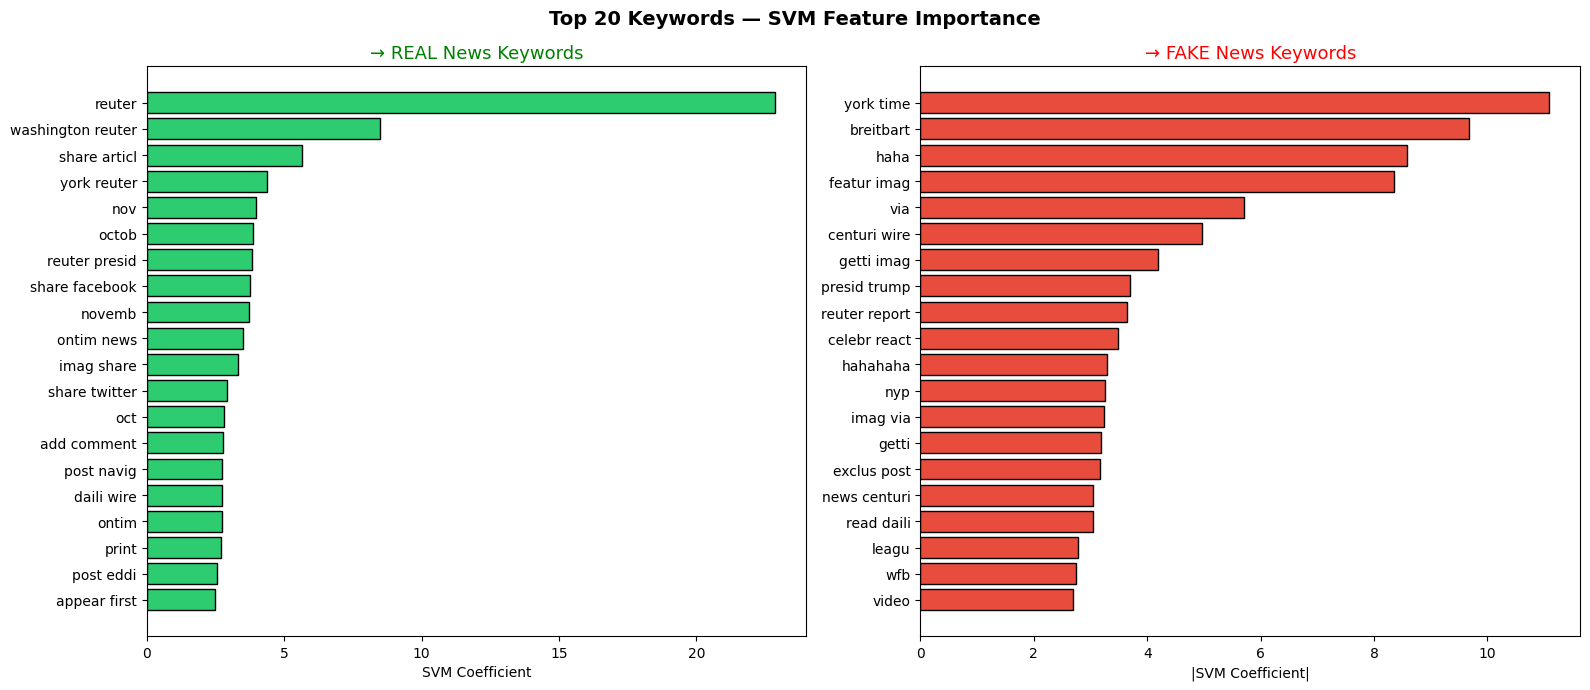

✅ Feature importance plot saved.


In [15]:
# CELL 11 — Top Words: Fake vs Real
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
feat  = np.array(pipeline.named_steps['tfidf'].get_feature_names_out())
coef  = pipeline.named_steps['svm'].coef_[0]
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top 20 Keywords — SVM Feature Importance", fontsize=14, fontweight='bold')

top_real = np.argsort(coef)[-top_n:][::-1]
axes[0].barh(feat[top_real][::-1], coef[top_real][::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('→ REAL News Keywords', color='green', fontsize=13)
axes[0].set_xlabel('SVM Coefficient')

top_fake = np.argsort(coef)[:top_n]
axes[1].barh(feat[top_fake][::-1], np.abs(coef[top_fake][::-1]), color='#e74c3c', edgecolor='black')
axes[1].set_title('→ FAKE News Keywords', color='red', fontsize=13)
axes[1].set_xlabel('|SVM Coefficient|')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved.")


In [14]:
# CELL 12 — Save & Download Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
joblib.dump(pipeline, 'fake_news_svm.pkl')
files.download('fake_news_svm.pkl')
print("✅ Model saved & download started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model saved & download started!


In [16]:
# CELL 13 — Predict on New Article
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def predict_article(title, text=""):
    raw     = title + " " + text
    cleaned = clean_text(raw)
    pred    = pipeline.predict([cleaned])[0]
    score   = pipeline.decision_function([cleaned])[0]
    label   = "✅  REAL" if pred == 1 else "🚫  FAKE"
    print("─" * 60)
    print(f"Title  : {title[:80]}")
    print(f"Result : {label}   |   Confidence score : {abs(score):.4f}")
    print("─" * 60)

# demo
predict_article(
    "Trump HUMILIATES Republicans In Latest Hissy Fit",
    "Donald Trump sure knows how to add insult to injury."
)
predict_article(
    "Reuters: Turkish gold trader implicates Erdogan in Iran money deal",
    "A Turkish-Iranian gold trader told jurors in a New York federal court."
)
predict_article(
    "NASA confirms water found on Moon surface",
    "Scientists announced the discovery of water ice deposits near the poles."
)

print("\n🎉 All done!")


────────────────────────────────────────────────────────────
Title  : Trump HUMILIATES Republicans In Latest Hissy Fit
Result : 🚫  FAKE   |   Confidence score : 0.4893
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
Title  : Reuters: Turkish gold trader implicates Erdogan in Iran money deal
Result : ✅  REAL   |   Confidence score : 2.5661
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
Title  : NASA confirms water found on Moon surface
Result : ✅  REAL   |   Confidence score : 0.1221
────────────────────────────────────────────────────────────

🎉 All done!
